# Anomaly Detection on Images

This domain is ussually called (VAD) Visual Anomaly Detection

With the Fmnist dataset some concepts of VAD are explained in the following section.

An example of VAD can be seen with images from the FMNIST DATASET

1.   Exploring the Dataset
2.   2 Models AE and PCA

# 1. DATASET - Fashion MNIST
Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60k examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes



<img src="https://github.com/buehlpa/Anomaly_Detection_Tutorial/blob/main/figures/fmnist_samples_5.png?raw=true" width="800" />

More information: check out the original repo @  https://github.com/zalandoresearch/fashion-mnist

## 1.1 Visualisation of the Dataset

1.1.1 Feature Extraction

let $X$ be the set of the original images $ \{x_{1},..,x_{n}\} $ with $x \in \mathbb{R}^{28x28}$. A pretrained  ResNet152$^{1}$ without the detectionhead  is used as a feature extractor $f_{\theta} : X → Z$ with $\theta$ = modelweights pretrained on the imagenet$^{2}$ dataset.
Let $ Z = \{ z_{1}, \dots, z_{n} \} $, where each $ z_{i} = f_{\theta}(x_{i}) \in \mathbb{R}^{d} $ and $d=2048$ is the dimensionality of the feature space extracted by the ResNet152 model. These high-dimensional feature vectors capture the abstract representations learned by the pretrained network.

<img src="https://github.com/buehlpa/Anomaly_Detection_Tutorial/blob/main/figures/f_extract.gif?raw=true" alt="feature extraction" width="700" >

1.1.1 Dimensionality Reduction

To visualize how these features are distributed, we apply t-SNE$^{3}$ to the set $ Z $, reducing the dimensionality from $ d $ to a 2D space. This unsupervised dimensionality reduction allows us to observe clusters and patterns in the data, providing insights into the inherent structure of the feature space derived from the original images $ X $.


<img src="https://github.com/buehlpa/Anomaly_Detection_Tutorial/blob/main/figures/tsne2d.gif?raw=true" alt="tsne2d" width="700" >


$^{1}$=https://pytorch.org/hub/pytorch_vision_resnet/
$^{2}$=https://image-net.org/
$^{3}$=https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html











### Excercise

below is the 2D representation of the trainingset of F-MNIST, every point has the according original image attached for a visual interpretation.


- Zoom in and explore the representation , can you spot the different clusters?
- Which classes do you expect to be separable the easiest? which might be harder?

In [ ]:
# @title FMNIST in TSNE 2d Representation
import folium
from PIL import Image
import requests
from io import BytesIO

# Load the image from the URL
url = 'https://github.com/buehlpa/Anomaly_Detection_Tutorial/blob/main/figures/tsne_images_features_all.png?raw=true'  # Replace with your image URL
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Create a folium map with a larger display size and no tiles
m = folium.Map(location=[0, 0], zoom_start=2, width='70%', height='800px', tiles=None)

# Set the background color to black using custom CSS
m.get_root().html.add_child(folium.Element('''<style>.leaflet-container {background: black;}</style>'''))

# Overlay the image on the map
folium.raster_layers.ImageOverlay(
    image=url,
    bounds=[[-90, -180], [90, 180]],
    opacity=1,
).add_to(m)

# Display the map with the image overlay
m


## 1.3 Extract the features and prepare the Dataset for model training & Evaluation


The F-mnist dataset and the pretrained model is already provide by the pytorch library. In the following the features are extracted for each image in the training and testset for Fmnist.



*   If you want to calculate the features by yourself, set the flag to False, else the features are downloaded

*    Run the 2 cells below





In [1]:
download_features=True # set this to False if you want calculate here

In [2]:
# @title CODE: Feature extraction
%%capture
import torch
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader,TensorDataset,SubsetRandomSampler
import random
import numpy as np


def data_transform(input_size):
    """
    prepares fmnist images to match requierements for ResNet
    """
    return transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.repeat(3, 1, 1)), # ResNet needs 3 channels
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]) # imagenetweigths


def extract_feature(root):
    """
    loads the resnet 152 and extracts features for all the iamges in Fmnist
    """

    model_ft = models.resnet152(pretrained=True)
    input_size = 224
    feature_extractor = torch.nn.Sequential(*list(model_ft.children())[:-1]).to('cuda')
    transform = data_transform(input_size)

    trainset = datasets.FashionMNIST(root, train=True, transform=transform, download=True)
    testset = datasets.FashionMNIST(root, train=False, transform=transform, download=True)

    train_loader = DataLoader(trainset, batch_size=256,shuffle=False)
    test_loader = DataLoader(testset, batch_size=256,shuffle=False)

    train_features = []
    test_features = []
    train_targets = []
    test_targets = []

    feature_extractor.eval()
    with torch.no_grad():
        for data,target in train_loader:
            data = data.to('cuda')
            feature = feature_extractor(data)
            train_features.append(feature.cpu())
            train_targets.append(target.cpu())
        train_features = torch.cat(train_features,0).squeeze()
        train_targets = torch.cat(train_targets,0)

        for data,target in test_loader:
            data = data.to('cuda')
            feature = feature_extractor(data)
            test_features.append(feature.cpu())
            test_targets.append(target.cpu())

        test_features = torch.cat(test_features,0).squeeze()
        test_targets = torch.cat(test_targets,0)

    return [train_features,train_targets],[test_features,test_targets]

path='/'
if not download_features:
  trainset, testset = extract_feature(path)
  print("features extracted!")

else:
  !pip install gdown

  train_id = '1majzRi4XvTfp3mz0Y_QM3zOK2Eq6Dsrl'
  !gdown --id $train_id -O trainset.pt

  test_id = '1r2vAfY_OCky9g1nDih3k8m1nS1kb7UlF'
  !gdown --id $test_id -O testset.pt

  trainset = torch.load('trainset.pt')
  testset = torch.load('testset.pt')

now there are train and testset list each containing of the data and labels

In [3]:
print(f'trainset size: {trainset[0].size()}') # each category has 1000 featurevectors, each featurevector is 2048 dims
print(f'trainset labels: {trainset[1]}')      # labels for each

# Label mapping
label_mapping = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

trainset size: torch.Size([60000, 2048])
trainset labels: tensor([9, 0, 0,  ..., 3, 0, 5])


# 2. Models



## 2.1 A Reconstruction based models
A reconstruction based model aims to accurately reconstruct its input.


### 2.1.1 PCA sklearn

For the PCA there are 3 steps:

- prepare the dataset
- Identfiy how many componets are need to explain a certain amount of varicane
- use the transformation on the testdata and evaluate


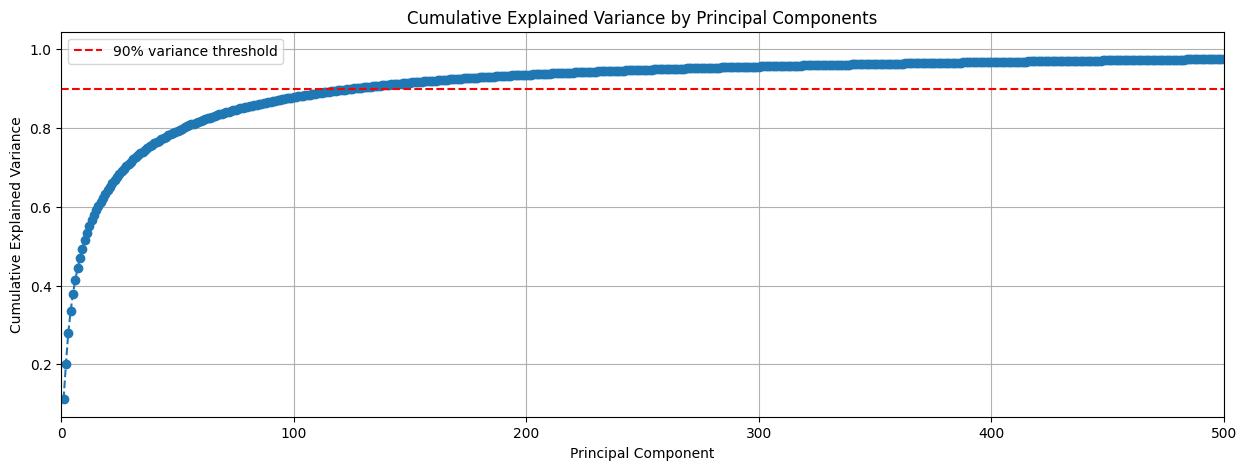

Number of components chosen to explain 90.0% of variance: 126


In [5]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


normal_label=0

############ Trainingset
train_data, train_targets = trainset # unpack the list to data and label
trainset_np = train_data.numpy()
scaler = MinMaxScaler(feature_range=(0, 1))
trainset_scaled = scaler.fit_transform(trainset_np)
trainset_scaled = trainset_scaled[train_targets == normal_label]

############# Testset
test_data, test_targets = testset
testset_np = test_data.numpy()
scaler = MinMaxScaler(feature_range=(0, 1))
testset_scaled = scaler.fit_transform(testset_np)

# all ones except for the normal class =0
test_labels = np.ones_like(test_targets)
test_labels[test_targets == normal_label] = 0


# Fit PCA without specifying n_components (to retain all components)
pca = PCA()
pca.fit(trainset_scaled)

# Cumulative explained variance
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(15, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance threshold')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.xlim(0,500)
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Choose number of components to explain 90% of the variance
threshold = 0.90
num_components = (cumulative_explained_variance >= threshold).argmax() + 1

print(f"Number of components chosen to explain {threshold*100}% of variance: {num_components}")



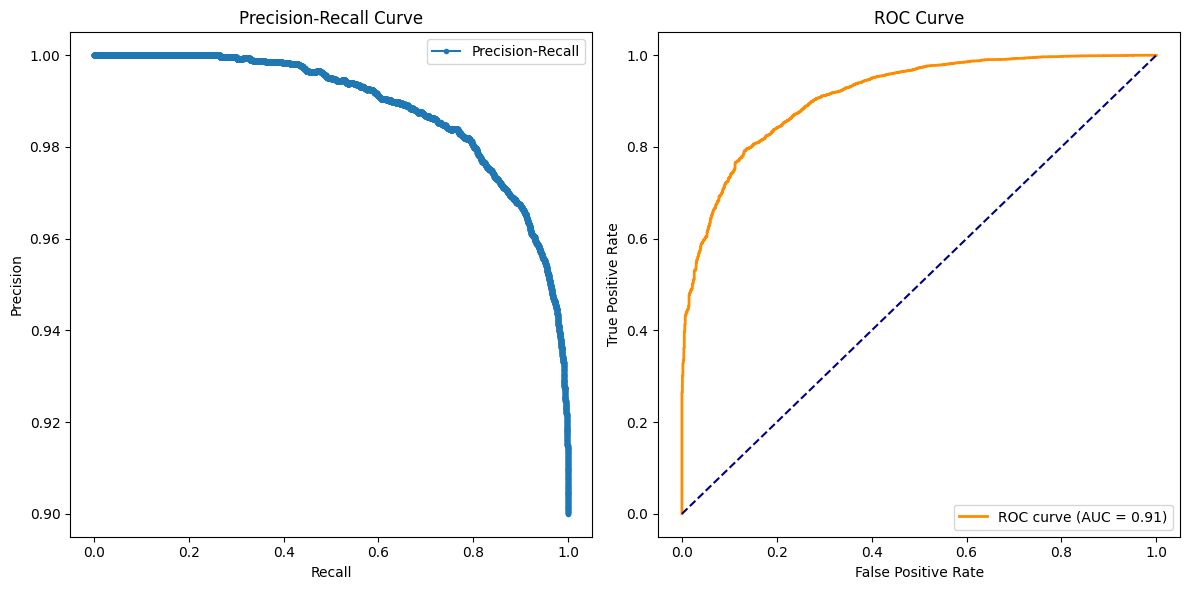

In [7]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
###### PCA based on chosen components
pca = PCA(n_components=num_components)
pca.fit(trainset_scaled)

testset_pca = pca.transform(testset_scaled)

# Calculate reconstruction error for the test set
test_reconstructed = pca.inverse_transform(testset_pca)
test_recon_error = np.mean((testset_scaled - test_reconstructed) ** 2, axis=1)

####### Evaluation
precision, recall, _ = precision_recall_curve(test_labels, test_recon_error)

# ROC curve and AUC
fpr, tpr, _ = roc_curve(test_labels, test_recon_error)
roc_auc = auc(fpr, tpr)

# Plot Precision-Recall and ROC Curve in one figure
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Precision-Recall curve
ax[0].set_title('Precision-Recall Curve')
ax[0].plot(recall, precision, marker='.', label='Precision-Recall')
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].legend()

# ROC curve
ax[1].set_title('ROC Curve')
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 2.1.2  Auto Encoder in pytorch

 Applied on the Feauterspace $Z$, a simple example is an Autoencoder $r_{\theta}:Z → Z$ which consists of an Encoder $\phi_{e} $,   and a Decoder $\phi_{d}$, where $r_{\theta}=\phi_{d}(\phi_{e}) $. To objective is to  reconstruct the input $z \sim \hat{z}$ without learning it by heart.

<img src="https://github.com/buehlpa/Anomaly_Detection_Tutorial/blob/main/figures/AE.gif?raw=true" alt="tsne2d" width="700" >


This section instantiates, trains (you can also download the weights), and evaluates a AE architecture on the tshirt class.

In [8]:
### the label 0 is chosen for evalutaion -> thsirt , if you train the model, one can also just use a subsample of the original data
normal_label=0
sample_size = 1000 #

In [9]:
# @title CODE:  Prepare the dataset
import numpy as np
from sklearn.preprocessing import MinMaxScaler
############ Trainingset

train_data, train_targets = trainset # unpack the list to data and label

# Convert PyTorch tensors to NumPy arrays
trainset_np = train_data.numpy()
scaler = MinMaxScaler(feature_range=(0, 1))
trainset_scaled = scaler.fit_transform(trainset_np)
train_data = torch.tensor(trainset_scaled)

train_normal = train_data[train_targets == normal_label]
train_labels = np.zeros(train_normal.shape[0]) # assign a new label 0, 0 = normal class

random_indices = np.random.randint(0, train_normal.shape[0], size=sample_size)
# Use the generated random indices to sample from the dataset
train_normal_sampled = train_normal[random_indices]



############# Testset
test_data, test_targets = testset
testset_np = test_data.numpy()
scaler = MinMaxScaler(feature_range=(0, 1))
testset_scaled = scaler.fit_transform(testset_np)
test_data = torch.tensor(testset_scaled)

# all ones except for the normal class =0
test_labels = np.ones_like(test_targets)
test_labels[test_targets == normal_label] = 0

In [ ]:
# @title CODE: AE Model
import torch
from torch.utils.data import DataLoader,TensorDataset
import torch.nn as nn
import torch.optim as optim

# AutoEncoder Model
class AutoencoderFeatures(nn.Module):
    def __init__(self):
        super(AutoencoderFeatures, self).__init__()

        self.input_dim = 2048
        self.hidden_dim_1 = 1024
        self.hidden_dim_2 = 512
        self.latent_dim = 64

        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, self.input_dim),
            nn.BatchNorm1d(self.input_dim),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Linear(self.input_dim, self.hidden_dim_1),
            nn.BatchNorm1d(self.hidden_dim_1),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Linear(self.hidden_dim_1, self.hidden_dim_2),
            nn.BatchNorm1d(self.hidden_dim_2),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Linear(self.hidden_dim_2, self.latent_dim)
        )

        # Decoder layers
        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, self.hidden_dim_2),
            nn.BatchNorm1d(self.hidden_dim_2),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Linear(self.hidden_dim_2, self.hidden_dim_1),
            nn.BatchNorm1d(self.hidden_dim_1),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Linear(self.hidden_dim_1, self.input_dim),
            nn.Sigmoid()  # Switch to sigmoid to bring output between 0 and 1
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


instantiate model, and parameters,

In [ ]:
# Instantiate the model, define the loss function and the optimizer
model=AutoencoderFeatures()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-7)

# Define training parameters
num_epochs = 200
batch_size = 24  # Set your desired batch size
min_delta = 1e-5  # Minimum change in the loss to be considered an improvement
patience = 5      # Number of epochs to wait before stopping if no improvement


In [ ]:
download_modelweights=True

In [ ]:
# @title CODE: AE Training
%%capture
if not download_modelweights:
  # Create a TensorDataset with the sampled data
  dataset = TensorDataset(torch.tensor(train_normal_sampled))
  data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

  # Counters
  best_loss = None
  trigger_times = 0 # patience counter

  # Training loop with early stopping
  for epoch in range(num_epochs):
      epoch_loss = 0.0
      for data_batch in data_loader:
          data = data_batch[0]  # Extract data from the batch tuple

          # Forward pass
          outputs = model(data)
          loss = criterion(outputs, data)

          # Backward pass and optimization
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          epoch_loss += loss.item() * data.size(0)

      # Compute average loss over the epoch
      avg_loss = epoch_loss / len(dataset)
      print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

      # Early stopping logic
      if best_loss is None:
          best_loss = avg_loss
      elif best_loss - avg_loss > min_delta:
          best_loss = avg_loss
          trigger_times = 0  #
      else:
          trigger_times += 1
          print(f'Early stopping counter: {trigger_times}/{patience}')
          if trigger_times >= patience:
              print('Early stopping!')
              break
else:
  weights_id = '1EEnTyjyptUk3TbBwJfVaXMBphbFpEMkJ'
  !gdown --id $weights_id -O ae_weights.pt

  ae_weights = torch.load('ae_weights.pt')
  model.load_state_dict(ae_weights)


<ipython-input-58-db701fb4bb3b>:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  reconstructed_data = model(torch.tensor(batch_data))
<ipython-input-58-db701fb4bb3b>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = criterion(reconstructed_data, torch.tensor(batch_data))


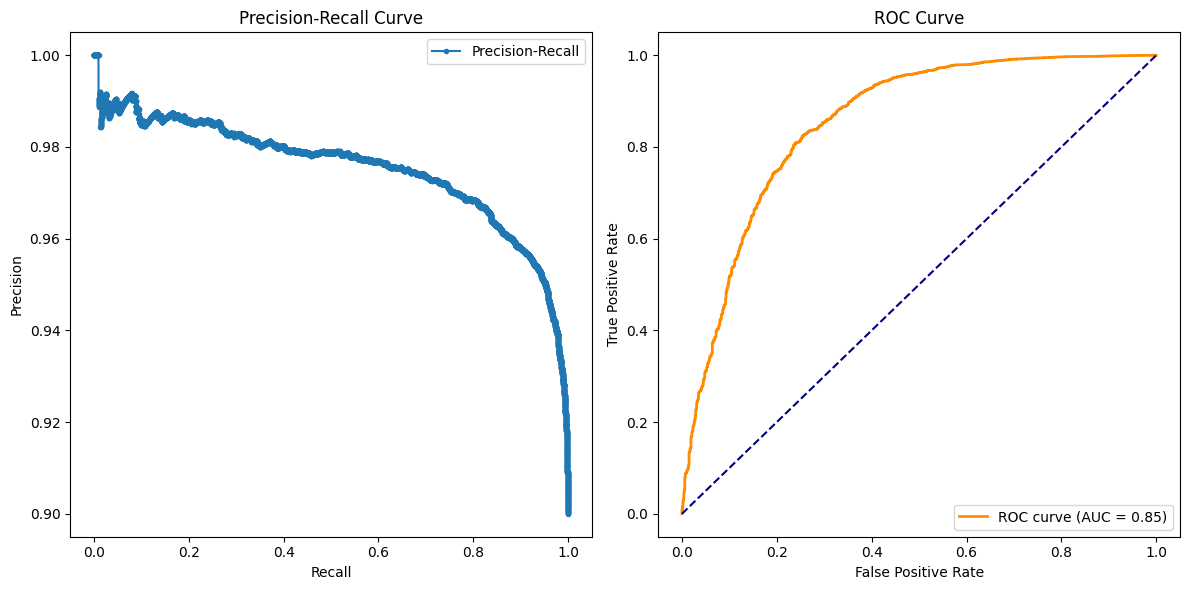

In [ ]:
# @title CODE: AE Evaluation

from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Put the model in evaluation mode
model.eval()

# Initialize variables to store results
test_loss = 0.0
all_recon_errors = []
all_labels = []

# Disable gradient calculation during evaluation
with torch.no_grad():
    for i in range(0, len(test_data), batch_size):
        # Get the batch of test data and corresponding true labels
        batch_data = test_data[i:i+batch_size]
        batch_labels = test_labels[i:i+batch_size]

        # Forward pass (Autoencoder reconstructs the input)
        reconstructed_data = model(torch.tensor(batch_data))

        # Compute reconstruction loss (e.g., MSE)
        loss = criterion(reconstructed_data, torch.tensor(batch_data))
        test_loss += loss.item() * batch_data.shape[0]

        # Compute reconstruction error for each data point in the batch
        recon_error = torch.mean((reconstructed_data - batch_data) ** 2, dim=1).cpu().numpy()

        # Append reconstruction errors and true labels for evaluation
        all_recon_errors.extend(recon_error)
        all_labels.extend(batch_labels)

# Convert the list of reconstruction errors and labels into numpy arrays
all_recon_errors = np.array(all_recon_errors)
all_labels = np.array(all_labels)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(all_labels, all_recon_errors)

# ROC curve and AUC
fpr, tpr, _ = roc_curve(all_labels, all_recon_errors)
roc_auc = auc(fpr, tpr)

# Plot Precision-Recall and ROC Curve in one figure
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Precision-Recall curve
ax[0].set_title('Precision-Recall Curve')
ax[0].plot(recall, precision, marker='.', label='Precision-Recall')
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].legend()

# ROC curve
ax[1].set_title('ROC Curve')
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
